# Dataset Exploration: Short-Range Tornado Predictor

Exploratory look at the actual data this project has collected and
built so far -- SPC storm reports, the ~40km coarse grid, positive
labels, and the full-scale (2014-2025) training dataset. Same spirit
as the sibling `tornet` project's `madis_data_exploration.ipynb`
(distribution checks, tornado-vs-non-tornado comparisons, correlation
structure) adapted to this project's actual data model: a dense grid
of HRRR forecast fields, not point weather-station observations.

This is a **descriptive** notebook, not a methodology change -- nothing
here alters any locked-in decision in `CLAUDE.md`.

## 1. Setup and Imports

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from tornado_predictor.grid import HrrrCoarseGrid

REPO_ROOT = Path.cwd().parent
DATA = REPO_ROOT / "data" / "processed"
INTERIM = REPO_ROOT / "data" / "interim"

plt.style.use("dark_background")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "#1e1e1e"
plt.rcParams["savefig.facecolor"] = "#1e1e1e"
np.random.seed(0)

## 2. SPC Tornado Reports (2014-2025)

The label source: every SPC-confirmed tornado report in the project's
verified training window (~Sept 2014 - Sept 2025, see `CLAUDE.md`
"Time binning").

In [2]:
reports = pd.read_csv(DATA / "spc_tornado_reports_2014_2025.csv", parse_dates=["timestamp_utc"])
print(f"{len(reports):,} reports, columns: {list(reports.columns)}")
reports.head()

15,294 reports, columns: ['event_id', 'timestamp_utc', 'start_lat', 'start_lon', 'end_lat', 'end_lon', 'length_mi', 'width_yd', 'path_wkt', 'ef_rating', 'state']


,event_id,timestamp_utc,start_lat,start_lon,end_lat,end_lon,length_mi,width_yd,path_wkt,ef_rating,state
0,2014_1401110637-01,2014-01-11 12:37:00,34.3328,-84.5286,34.3476,-84.4811,2.90,10,"LINESTRING (-84.5286 34.3328, -84.4811 34.3476)",0.0,GA
1,2014_1401111432-02,2014-01-11 20:32:00,36.8769,-76.6721,36.8902,-76.6409,1.95,50,"LINESTRING (-76.6721 36.8769, -76.6409 36.8902)",0.0,VA
2,2014_1401111432-01,2014-01-11 20:32:00,37.0250,-76.6377,37.0354,-76.6167,1.36,100,"LINESTRING (-76.6377 37.025, -76.6167 37.0354)",0.0,VA
3,2014_1401111450-01,2014-01-11 20:50:00,37.0800,-76.3000,37.0900,-76.2850,1.08,75,"LINESTRING (-76.3 37.08, -76.285 37.09)",0.0,VA
4,2014_1402201425-01,2014-02-20 20:25:00,39.5180,-90.8410,39.6330,-90.6700,12.09,80,"LINESTRING (-90.841 39.518, -90.67 39.633)",2.0,IL


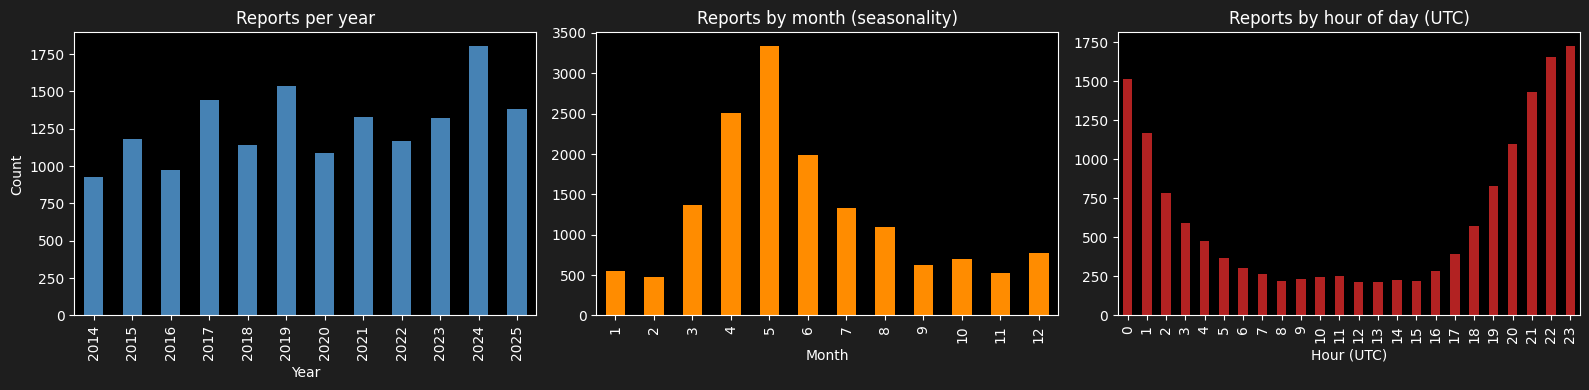

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

reports["timestamp_utc"].dt.year.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Reports per year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

reports["timestamp_utc"].dt.month.value_counts().sort_index().plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Reports by month (seasonality)")
axes[1].set_xlabel("Month")

reports["timestamp_utc"].dt.hour.value_counts().sort_index().plot(kind="bar", ax=axes[2], color="firebrick")
axes[2].set_title("Reports by hour of day (UTC)")
axes[2].set_xlabel("Hour (UTC)")

plt.tight_layout()
plt.show()

Expected patterns to sanity-check against: a strong spring/early-summer
peak (April-June) in the monthly chart, and a late-afternoon-to-evening
peak (roughly 20:00-03:00 UTC, i.e. mid-afternoon to evening Central
Time) in the hourly chart -- the classic tornado diurnal cycle. If
either pattern is absent, that would suggest a parsing bug, not a real
finding.

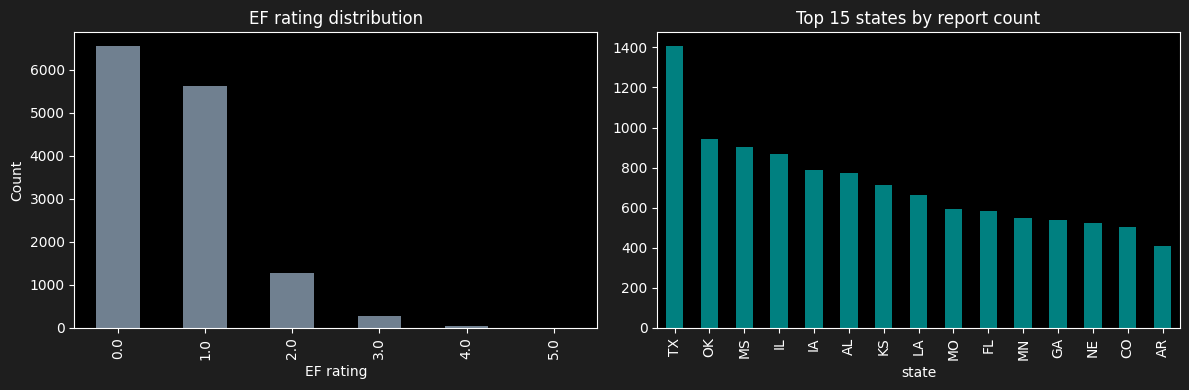

ef_rating
0.0    47.5%
1.0    40.9%
2.0     9.2%
3.0     2.1%
4.0     0.3%
5.0     0.0%
Name: proportion, dtype: object


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

reports["ef_rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="slategray")
axes[0].set_title("EF rating distribution")
axes[0].set_xlabel("EF rating")
axes[0].set_ylabel("Count")

reports["state"].value_counts().head(15).plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_title("Top 15 states by report count")

plt.tight_layout()
plt.show()

print(reports["ef_rating"].value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + "%")

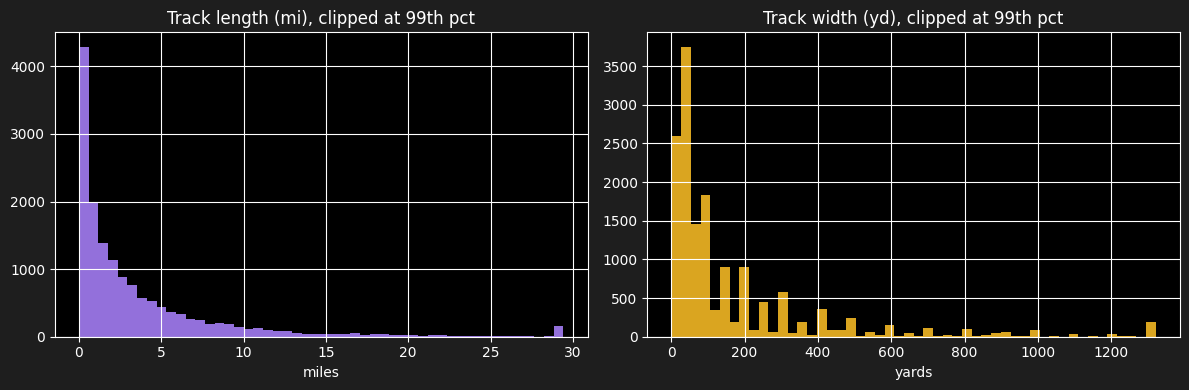

          length_mi      width_yd
count  15294.000000  15294.000000
mean       3.787510    176.377076
std        6.341554    266.657235
min        0.010000      1.000000
25%        0.500000     50.000000
50%        1.760000     80.000000
75%        4.620000    200.000000
max      168.530000   3960.000000

zero-length (point) tracks: 0 (0.0%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

reports["length_mi"].clip(upper=reports["length_mi"].quantile(0.99)).hist(bins=50, ax=axes[0], color="mediumpurple")
axes[0].set_title("Track length (mi), clipped at 99th pct")
axes[0].set_xlabel("miles")

reports["width_yd"].clip(upper=reports["width_yd"].quantile(0.99)).hist(bins=50, ax=axes[1], color="goldenrod")
axes[1].set_title("Track width (yd), clipped at 99th pct")
axes[1].set_xlabel("yards")

plt.tight_layout()
plt.show()

print(reports[["length_mi", "width_yd"]].describe())
print(f"\nzero-length (point) tracks: {(reports['length_mi'] == 0).sum():,} ({(reports['length_mi'] == 0).mean():.1%})")

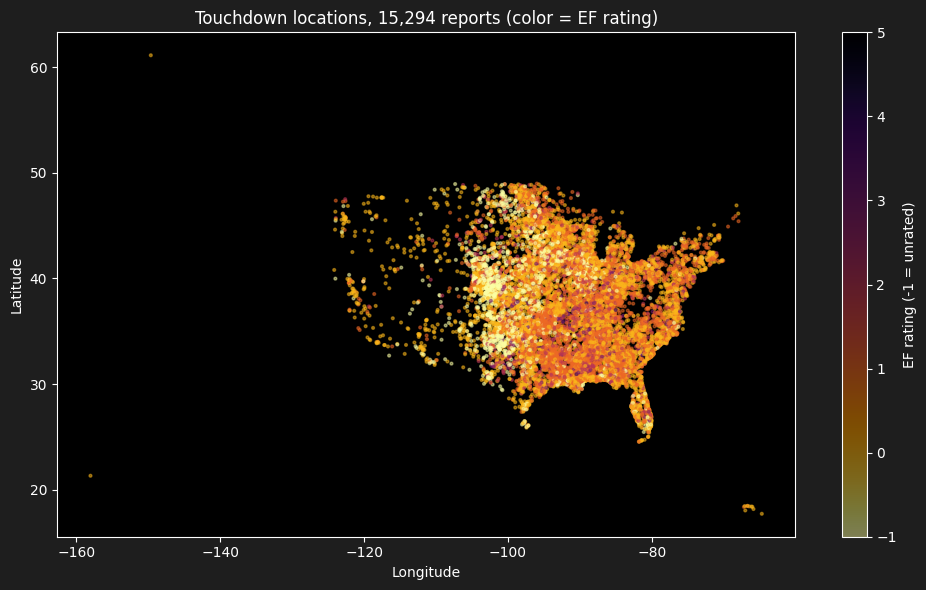

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    reports["start_lon"], reports["start_lat"],
    c=reports["ef_rating"].fillna(-1), cmap="inferno_r", s=4, alpha=0.5,
)
ax.set_title(f"Touchdown locations, {len(reports):,} reports (color = EF rating)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(sc, ax=ax, label="EF rating (-1 = unrated)")
plt.tight_layout()
plt.show()

## 3. The ~40km Grid

Block-aligned stride coarsening of HRRR's native grid (see `CLAUDE.md`
"Grid definition"). Plotting every cell center shows the full native
HRRR domain this project uses -- including the ocean/Mexico/Canada
edges that are a real, confirmed consequence of Lambert Conformal
Conic projection curvature, not clipped to a CONUS land boundary.

grid shape: 81 rows x 138 cols = 11,178 cells
cell size: 39 km
lon range: -133.7 to -61.5
lat range: 21.3 to 52.3


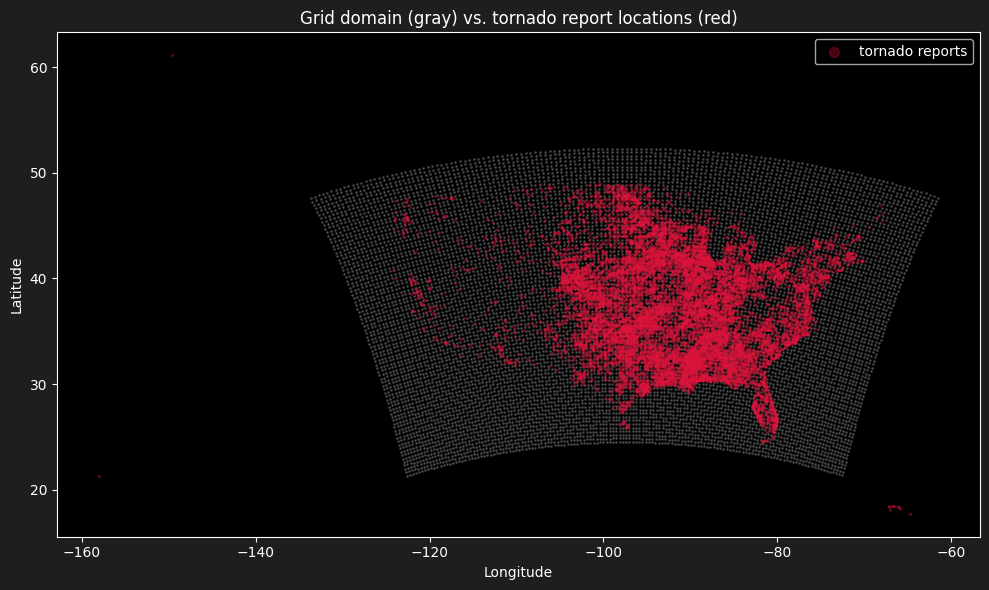

In [7]:
grid = HrrrCoarseGrid.from_netcdf(DATA / "hrrr_coarse_grid_stride13.nc")
print(f"grid shape: {grid.n_rows} rows x {grid.n_cols} cols = {grid.n_rows * grid.n_cols:,} cells")
print(f"cell size: {grid.cell_size_m / 1000:.0f} km")
print(f"lon range: {grid.lon_center.min():.1f} to {grid.lon_center.max():.1f}")
print(f"lat range: {grid.lat_center.min():.1f} to {grid.lat_center.max():.1f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(grid.lon_center.ravel(), grid.lat_center.ravel(), s=1, color="gray", alpha=0.4)
ax.scatter(reports["start_lon"], reports["start_lat"], s=2, color="crimson", alpha=0.3, label="tornado reports")
ax.set_title("Grid domain (gray) vs. tornado report locations (red)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

## 4. Positive Labels

`tornado_labels_2014_2025.csv` -- one row per `(event, run init_time,
bin_index, row, col)` a report's buffered track intersects (see
`CLAUDE.md` "Labeling"). This section looks at the label table
independent of any specific run/bin, collapsing to genuine spatial
(row, col) and temporal (event) structure.

In [8]:
labels = pd.read_csv(DATA / "tornado_labels_2014_2025.csv", parse_dates=["init_time"])
print(f"{len(labels):,} label rows (event x run x cell)")

unique_event_cell = labels.drop_duplicates(subset=["event_id", "row", "col"])
print(f"{len(unique_event_cell):,} unique (event, cell) pairs")

unique_sample_cell = labels.drop_duplicates(subset=["init_time", "bin_index", "row", "col"])
print(f"{len(unique_sample_cell):,} unique (run, bin, cell) positive samples")

147,440 label rows (event x run x cell)
18,430 unique (event, cell) pairs
111,580 unique (run, bin, cell) positive samples


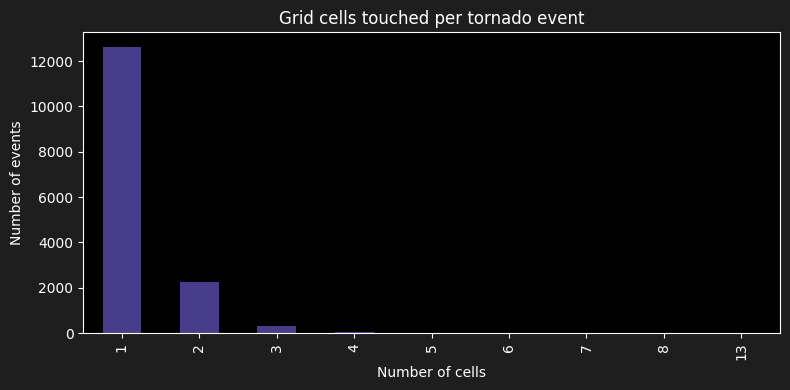

count    15282.000000
mean         1.205994
std          0.507359
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         13.000000
dtype: float64

max cells for one event: 2021_2112102054-01 (13 cells)


In [9]:
cells_per_event = unique_event_cell.groupby("event_id").size()
fig, ax = plt.subplots(figsize=(8, 4))
cells_per_event.value_counts().sort_index().plot(kind="bar", ax=ax, color="darkslateblue")
ax.set_title("Grid cells touched per tornado event")
ax.set_xlabel("Number of cells")
ax.set_ylabel("Number of events")
plt.tight_layout()
plt.show()

print(cells_per_event.describe())
print(f"\nmax cells for one event: {cells_per_event.idxmax()} ({cells_per_event.max()} cells)")

/var/folders/2k/0qh4r79d2wl0b4skmgc5p80c0000gr/T/ipykernel_86038/931597449.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(grid.lon_center, grid.lat_center, np.ma.masked_equal(density_grid, 0), cmap="hot_r", shading="nearest")


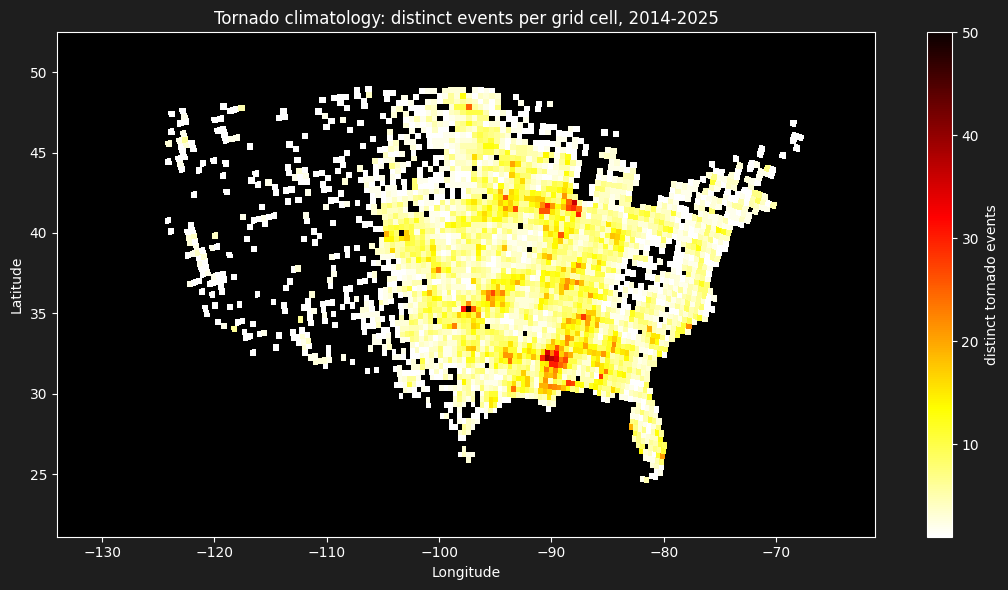

In [10]:
density = unique_event_cell.groupby(["row", "col"]).size()
density_grid = np.zeros((grid.n_rows, grid.n_cols))
density_grid[density.index.get_level_values("row"), density.index.get_level_values("col")] = density.values

fig, ax = plt.subplots(figsize=(11, 6))
pcm = ax.pcolormesh(grid.lon_center, grid.lat_center, np.ma.masked_equal(density_grid, 0), cmap="hot_r", shading="nearest")
ax.set_title("Tornado climatology: distinct events per grid cell, 2014-2025")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(pcm, ax=ax, label="distinct tornado events")
plt.tight_layout()
plt.show()

Expect this to visually reproduce the well-known US tornado climatology
(Great Plains / Dixie Alley / Southeast concentration) as a sanity
check that grid assignment and labeling are geometrically correct --
not just passing unit tests, but producing a real, recognizable
physical pattern.

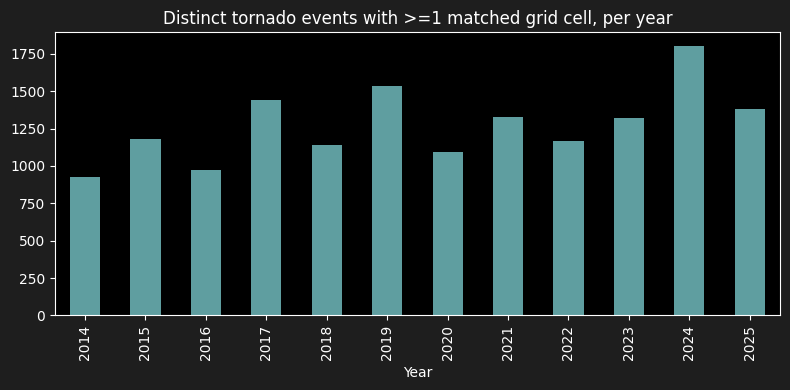

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
unique_event_cell.drop_duplicates("event_id")["init_time"].dt.year.value_counts().sort_index().plot(
    kind="bar", ax=ax, color="cadetblue"
)
ax.set_title("Distinct tornado events with >=1 matched grid cell, per year")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()

## 5. Full-Scale Training Dataset (3,578 train / 682 val)

The consolidated feature+label dataset from the completed full-scale
build (`CLAUDE.md` "Full-scale build"): every date with a confirmed SPC
report, 2014-2025, plus 300 quiet dates.

In [12]:
train_ds = xr.open_dataset(DATA / "training_dataset_train_full.nc").load()
val_ds = xr.open_dataset(DATA / "training_dataset_val_full.nc").load()

print("train:", dict(train_ds.sizes))
print("val:  ", dict(val_ds.sizes))
print("\nvariables:", [v for v in train_ds.data_vars])

train: {'sample': 5078, 'row': 81, 'col': 138}
val:   {'sample': 980, 'row': 81, 'col': 138}

variables: ['cape_mean', 'cape_max', 'cin_mean', 'cin_max', 'srh_0_1km_mean', 'srh_0_1km_max', 'srh_0_3km_mean', 'srh_0_3km_max', 't2m_mean', 't2m_max', 'd2m_mean', 'd2m_max', 'shear_0_6km_mean', 'shear_0_6km_max', 'label']


In [13]:
def summarize(ds, name):
    label = ds["label"].values
    n_samples = label.shape[0]
    active_maps = (label.reshape(n_samples, -1).sum(axis=1) > 0).sum()
    pos_cells = int((label == 1).sum())
    total_cells = label.size
    print(f"{name}: {n_samples:,} samples | {active_maps:,} active maps ({active_maps / n_samples:.1%}) "
          f"| {pos_cells:,} positive cells / {total_cells:,} total ({pos_cells / total_cells:.2e})")

summarize(train_ds, "train")
summarize(val_ds, "val")

train: 5,078 samples | 3,208 active maps (63.2%) | 12,090 positive cells / 56,761,884 total (2.13e-04)
val: 980 samples | 631 active maps (64.4%) | 2,327 positive cells / 10,954,440 total (2.12e-04)


### Tornado (active) vs. non-tornado (quiet) samples, train vs. val

This project has no separate held-out test set -- only train/val (see
`CLAUDE.md` "Train/val split"), split by UTC calendar date via the
TorNet-adapted mod-20 rule. A sample is "tornado" (active) if its grid
map contains >=1 positive cell, "non-tornado" (quiet) otherwise -- the
same active/quiet distinction `QuietMapDownsampler` operates on.

       tornado (active)  non-tornado (quiet)
train              3208                 1870
val                 631                  349

      tornado (active) non-tornado (quiet)
train            63.2%               36.8%
val              64.4%               35.6%


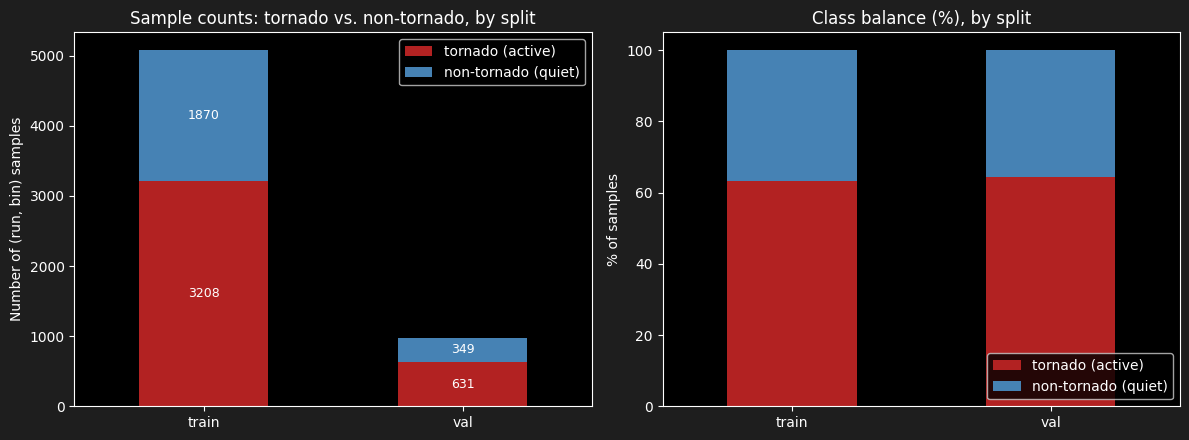

In [14]:
def active_quiet_counts(ds):
    label = ds["label"].values
    is_active = label.reshape(label.shape[0], -1).sum(axis=1) > 0
    return int(is_active.sum()), int((~is_active).sum())

train_active, train_quiet = active_quiet_counts(train_ds)
val_active, val_quiet = active_quiet_counts(val_ds)

counts = pd.DataFrame(
    {"tornado (active)": [train_active, val_active], "non-tornado (quiet)": [train_quiet, val_quiet]},
    index=["train", "val"],
)
print(counts)
print()
print((counts.div(counts.sum(axis=1), axis=0) * 100).round(1).astype(str) + "%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

counts.plot(kind="bar", stacked=True, ax=axes[0], color=["firebrick", "steelblue"])
axes[0].set_title("Sample counts: tornado vs. non-tornado, by split")
axes[0].set_ylabel("Number of (run, bin) samples")
axes[0].tick_params(axis="x", rotation=0)
for container in axes[0].containers:
    axes[0].bar_label(container, label_type="center", fontsize=9, color="white")

(counts.div(counts.sum(axis=1), axis=0) * 100).plot(
    kind="bar", stacked=True, ax=axes[1], color=["firebrick", "steelblue"]
)
axes[1].set_title("Class balance (%), by split")
axes[1].set_ylabel("% of samples")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [15]:
FIELDS = ["cape", "cin", "srh_0_1km", "srh_0_3km", "shear_0_6km", "t2m", "d2m"]

stats_rows = []
for field in FIELDS:
    v = train_ds[f"{field}_mean"].values
    stats_rows.append({
        "field": field, "mean": v.mean(), "std": v.std(),
        "min": v.min(), "max": v.max(), "p99": np.percentile(v, 99),
    })
stats_df = pd.DataFrame(stats_rows).set_index("field")
stats_df.round(2)

,mean,std,min,max,p99
field,,,,,
cape,475.140015,898.539978,0.000000,6835.270020,3685.090088
cin,-18.780001,55.509998,-1661.359985,4.280000,0.000000
srh_0_1km,31.320000,62.959999,-968.609985,1549.689941,283.579987
srh_0_3km,84.470001,94.830002,-994.000000,2799.439941,446.440002
shear_0_6km,15.510000,9.580000,0.070000,82.110001,44.540001
t2m,290.670013,10.480000,231.350006,321.859985,308.869995
d2m,282.640015,10.890000,192.119995,303.329987,298.769989


### Positive vs. negative cell feature separation

Does each field actually discriminate tornadic from non-tornadic
cells, the way the "Validation against a documented case" spot-check
in `CLAUDE.md` suggested (rising helicity, sustained CAPE)? Checked
here across the *entire* dataset rather than one case, using all
positive cells (rare, ~6-9k) against every negative cell (~40-48M) --
full arrays, no subsampling needed since these are simple vectorized
comparisons.

12,090 positive cells, 56,749,794 negative cells


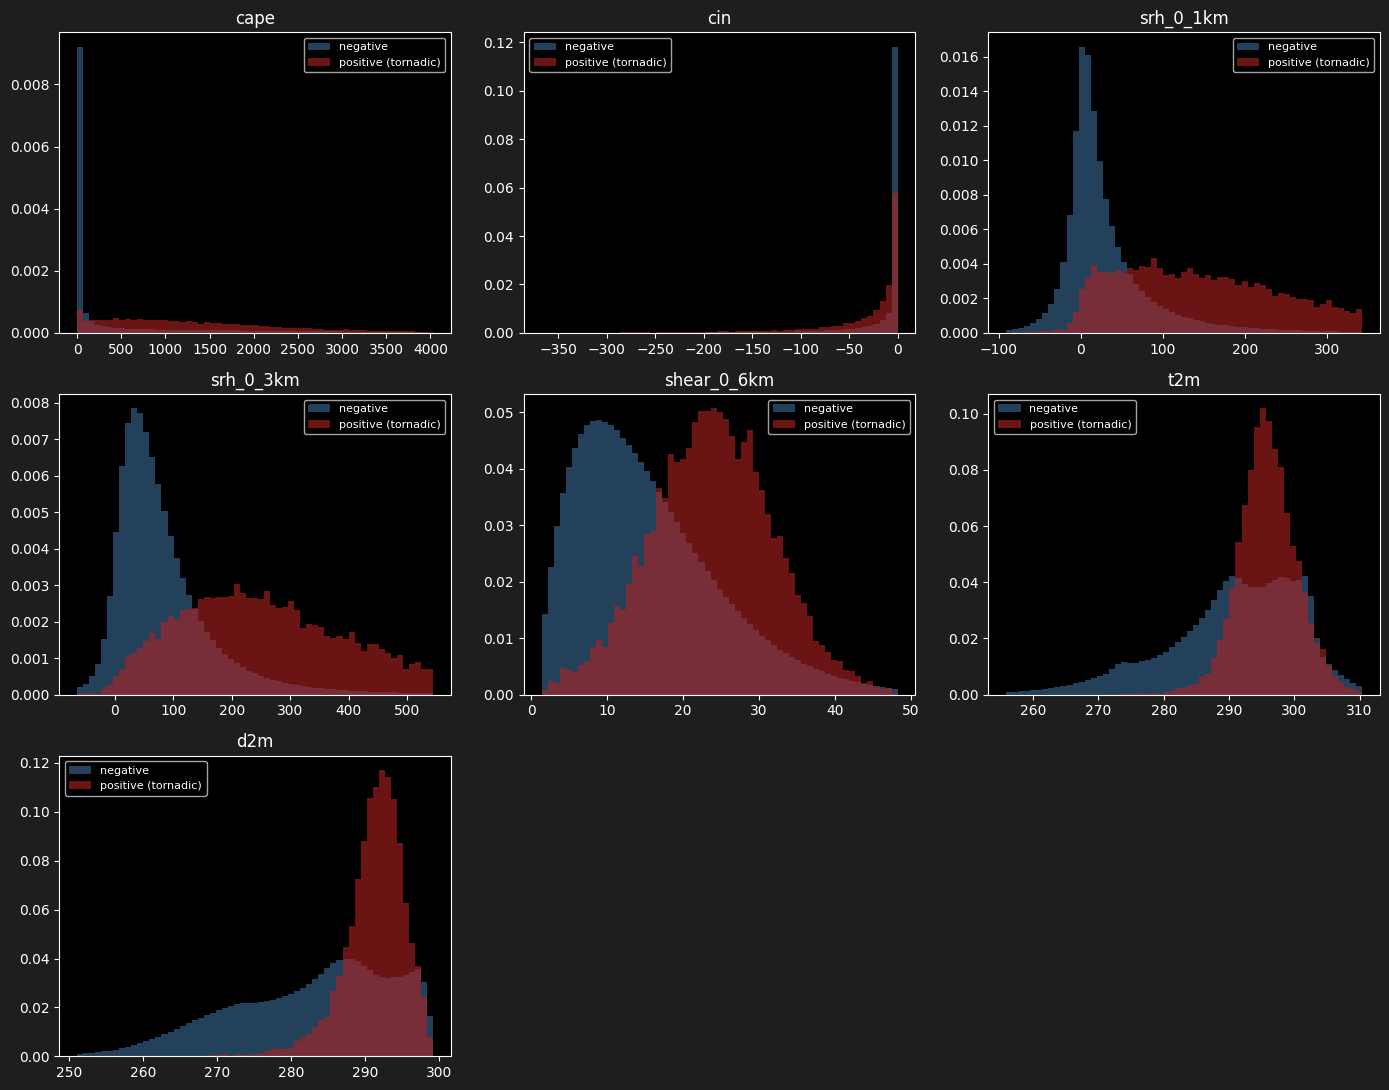

In [16]:
label_flat = train_ds["label"].values.ravel().astype(bool)
print(f"{label_flat.sum():,} positive cells, {(~label_flat).sum():,} negative cells")

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
cohens_d = {}
for ax, field in zip(axes.ravel(), FIELDS):
    v = train_ds[f"{field}_mean"].values.ravel()
    pos, neg = v[label_flat], v[~label_flat]
    lo, hi = np.percentile(v, [0.5, 99.5])
    bins = np.linspace(lo, hi, 60)
    ax.hist(neg, bins=bins, density=True, alpha=0.5, label="negative", color="steelblue")
    ax.hist(pos, bins=bins, density=True, alpha=0.6, label="positive (tornadic)", color="firebrick")
    ax.set_title(field)
    ax.legend(fontsize=8)
    pooled_std = np.sqrt((pos.std() ** 2 + neg.std() ** 2) / 2)
    cohens_d[field] = (pos.mean() - neg.mean()) / pooled_std if pooled_std > 0 else np.nan

for ax in axes.ravel()[len(FIELDS):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

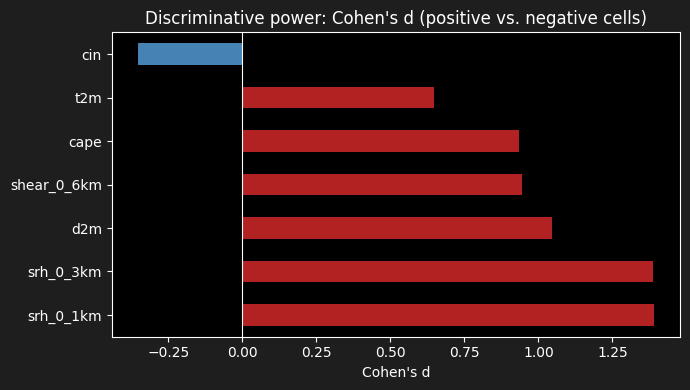

srh_0_1km      1.391
srh_0_3km      1.386
d2m            1.047
shear_0_6km    0.945
cape           0.933
t2m            0.648
cin           -0.354
dtype: float32


In [17]:
d_series = pd.Series(cohens_d).sort_values(key=np.abs, ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
d_series.plot(kind="barh", ax=ax, color=["firebrick" if x > 0 else "steelblue" for x in d_series])
ax.set_title("Discriminative power: Cohen's d (positive vs. negative cells)")
ax.set_xlabel("Cohen's d")
ax.axvline(0, color="white", linewidth=0.8)
plt.tight_layout()
plt.show()

print(d_series.round(3))

Rule of thumb: |d| ~ 0.2 small, ~0.5 medium, ~0.8 large. Same story as before, slightly sharper with more data: `srh_0_1km` and `srh_0_3km` (d ~1.39) are the strongest, `d2m` (d ~1.05), `shear_0_6km` (d ~0.95), and `cape` (d ~0.93) all show **large** effect sizes, `t2m` (d ~0.65) is medium, and `cin` (d ~-0.35, correctly negative -- weaker capping near tornadic cells) is small. This is a stronger per-cell signal than the model's own inference-time probability separation (`CLAUDE.md` "Inference + sanity check", ~40-90x but capped well below 1.0) would suggest on its own -- the *features* clearly separate tornadic from non-tornadic cells at the population level; the *model's* more modest absolute confidence traces to `FocalLoss`'s `alpha=0.25` down-weighting the rare positive class (already documented, not re-litigated here), not to weak underlying features.

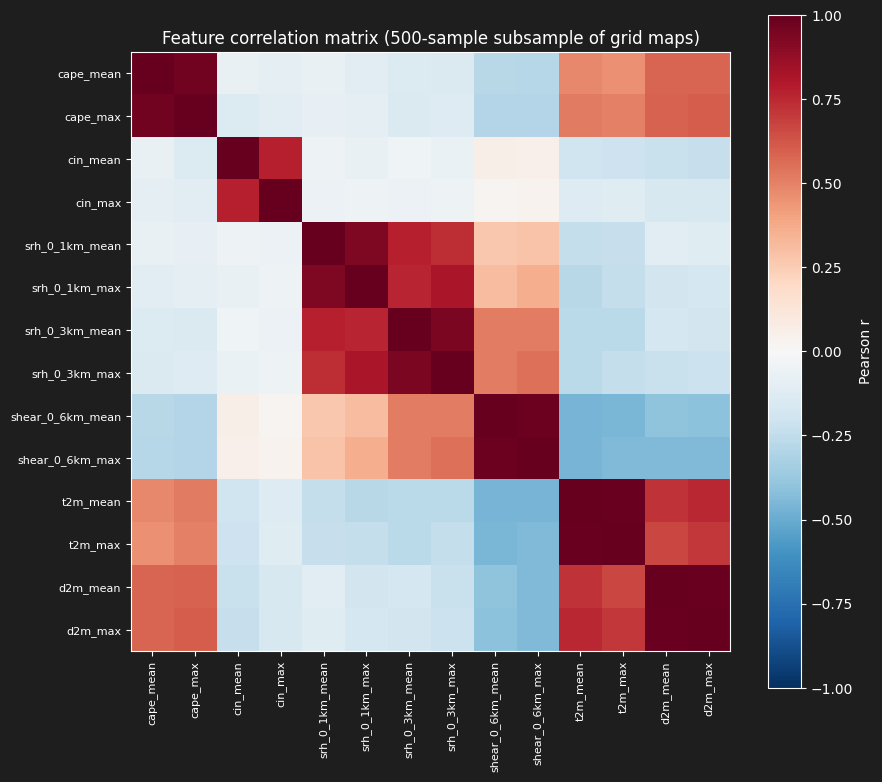

In [18]:
ALL_VARS = [f"{f}_{stat}" for f in FIELDS for stat in ("mean", "max")]
sample_idx = np.random.choice(train_ds.sizes["sample"], size=min(500, train_ds.sizes["sample"]), replace=False)
feat_matrix = np.stack([train_ds[v].isel(sample=sample_idx).values.ravel() for v in ALL_VARS], axis=0)
corr = np.corrcoef(feat_matrix)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(ALL_VARS)))
ax.set_yticks(range(len(ALL_VARS)))
ax.set_xticklabels(ALL_VARS, rotation=90, fontsize=8)
ax.set_yticklabels(ALL_VARS, fontsize=8)
ax.set_title("Feature correlation matrix (500-sample subsample of grid maps)")
plt.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

Expect `_mean` and `_max` of the same field to be strongly correlated
with each other (same underlying field, different pooling statistic)
-- if not, that's worth investigating. `srh_0_1km` and `srh_0_3km` are
also physically related (nested layers of the same helicity profile)
and expected to correlate. `t2m`/`d2m` correlating moderately is also
physically sensible (both track the same air mass's temperature).

## 6. Pipeline Coverage: Which Runs Are Actually In the Dataset

`data/interim/scaled_build_v2/manifest.json` records the full-scale build v2's per-run outcome (see `CLAUDE.md` "Full-scale build v2"). v2 pulls a *run* (full init_time, not just a date) for every report-covering anchor plus quiet dates -- a different, finer unit than v1's one-run-per-date manifest. Visualizing failures over time.

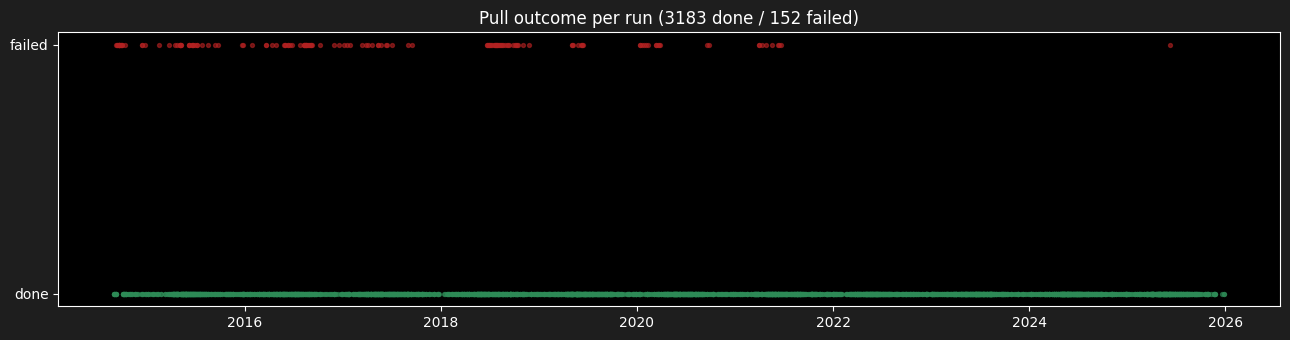

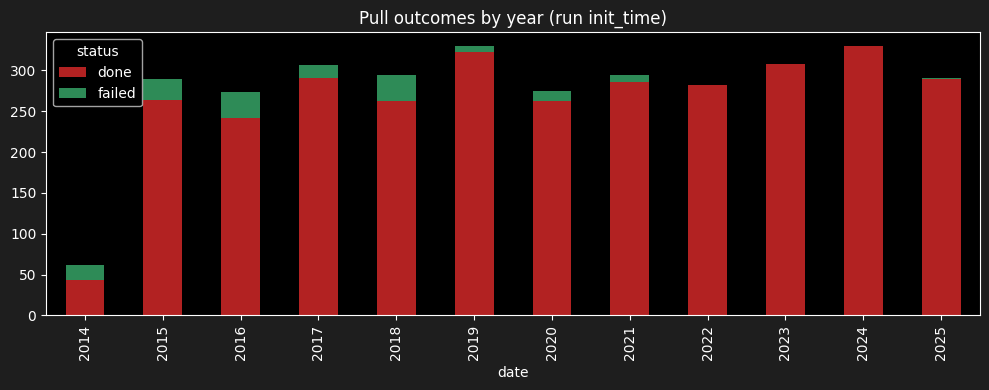

In [19]:
manifest = json.loads((INTERIM / "scaled_build_v2" / "manifest.json").read_text())
manifest_df = pd.DataFrame([
    {"date": pd.Timestamp(k), "status": v["status"]} for k, v in manifest.items()
]).sort_values("date")

fig, ax = plt.subplots(figsize=(13, 3.5))
for status, color in [("done", "seagreen"), ("failed", "firebrick")]:
    subset = manifest_df[manifest_df["status"] == status]
    ax.scatter(subset["date"], [status] * len(subset), s=8, color=color, alpha=0.6)
ax.set_title(f"Pull outcome per run ({(manifest_df['status'] == 'done').sum()} done / "
             f"{(manifest_df['status'] == 'failed').sum()} failed)")
plt.tight_layout()
plt.show()

by_year = manifest_df.groupby([manifest_df["date"].dt.year, "status"]).size().unstack(fill_value=0)
by_year.plot(kind="bar", stacked=True, figsize=(10, 4), color=["firebrick", "seagreen"])
plt.title("Pull outcomes by year (run init_time)")
plt.tight_layout()
plt.show()

Unlike v1's failure pattern (clustered entirely in 2014-2018, an archive-availability effect), v2's remaining failures are scattered across 2014-2021 and 2025 with no strong year concentration -- consistent with the failure-reason breakdown in `CLAUDE.md` ("Full-scale build v2"): most were transient `EOFError`/`ConnectionError`/`PrematureEndOfFileError` rather than genuine archive gaps, and a retry pass already recovered 40 of the original 192. The remaining failures are simply missing data, not silently wrong data -- `process_one_run` only marks a run "done" after a real `build_dataset` success.

## 7. Summary

- **Reports**: 15,294 SPC tornado reports, 2014-2025, with the expected
  spring-peak seasonality and late-afternoon/evening diurnal cycle --
  matches known tornado climatology, a good sanity check on the SPC
  parser.
- **Grid**: 81x138 (11,178) cells at ~39km resolution, full native HRRR
  domain (extends over ocean/Mexico/Canada at the edges by design).
- **Labels**: positive-label spatial density reproduces the real US
  tornado climatology (Plains / Dixie Alley concentration) when
  aggregated onto the grid -- a strong end-to-end geometric sanity
  check on grid assignment + track buffering.
- **Full-scale dataset (v2)**: 5,078 train / 980 val samples, 63.2% /
  64.4% active maps -- up substantially from v1's 46% / 48%, the
  direct result of the report-covering run-selection fix (see
  `CLAUDE.md` "Full-scale build v2"). Most fields show a **large**
  effect-size separation between positive and negative cells (Cohen's
  d ~0.9-1.4, strongest for SRH), stronger than expected going in --
  the raw features are strongly discriminative at the population
  level. The model's own inference-time finding of a more modest,
  capped probability separation (`CLAUDE.md` "Inference + sanity
  check") is therefore better explained by `FocalLoss`'s `alpha=0.25`
  down-weighting rare positives than by the features themselves being
  weak -- a concrete lead for the still-open alpha-retuning question.
- **Coverage**: 95.5% of targeted runs pulled successfully after one
  retry pass; remaining failures are scattered and mostly
  transient-looking, not a systemic gap like v1's early-archive
  clustering.

No methodology changes suggested by this exploration -- it's consistent
with, and adds visual/quantitative confirmation to, everything already
documented in `CLAUDE.md`.